<a href="https://colab.research.google.com/github/jahnavitelsang/Assignment2026/blob/main/LGBM_%26_XGBM_assignment13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv('/content/diabetes (1).csv')

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.shape

(768, 9)

In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
print('There are no missing values in the data')

There are no missing values in the data


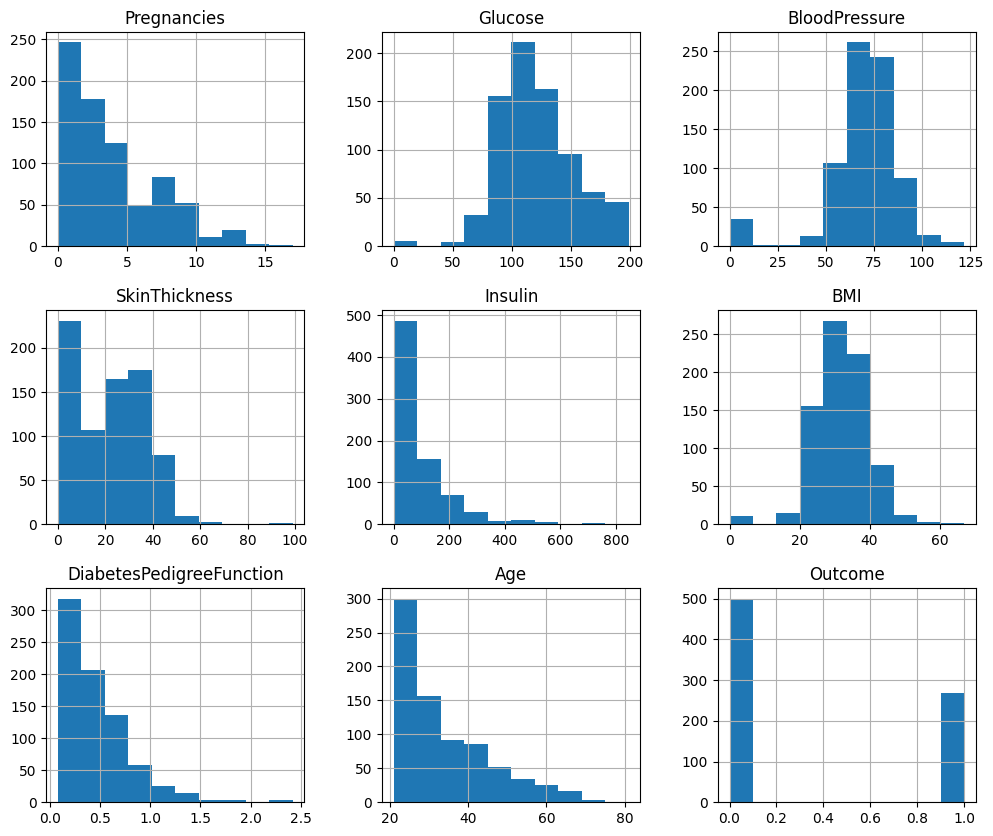

In [ ]:
df.hist(figsize=(12,10))
plt.show()


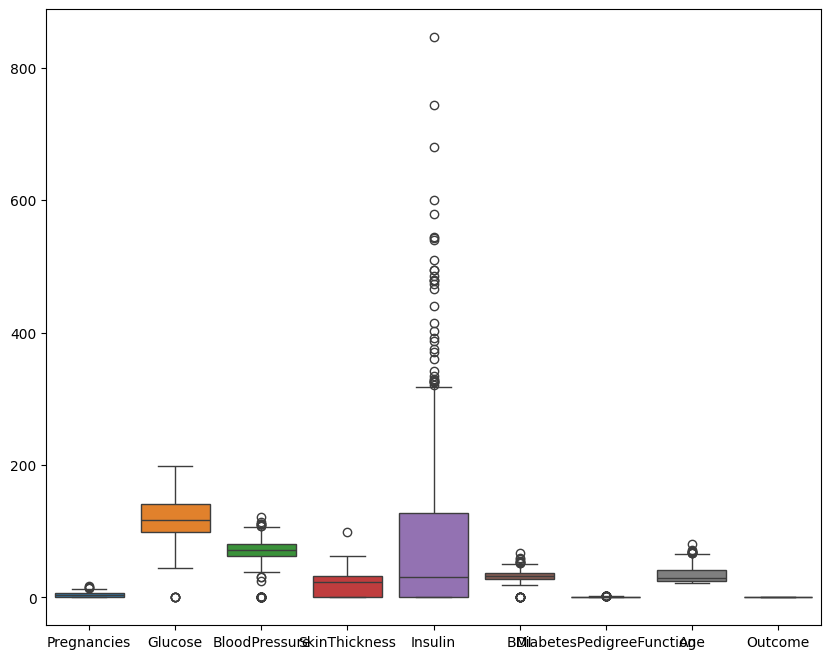

In [ ]:
plt.figure(figsize=(10,8))
sns.boxplot(data=df)
plt.xticks()
plt.show()

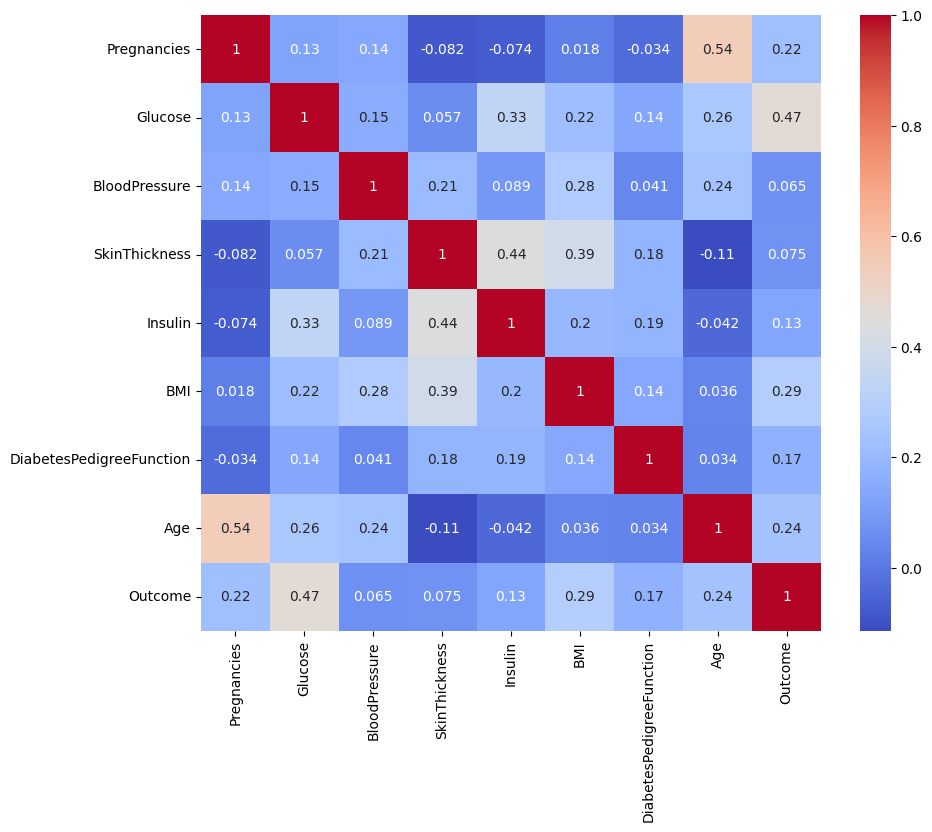

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.show()


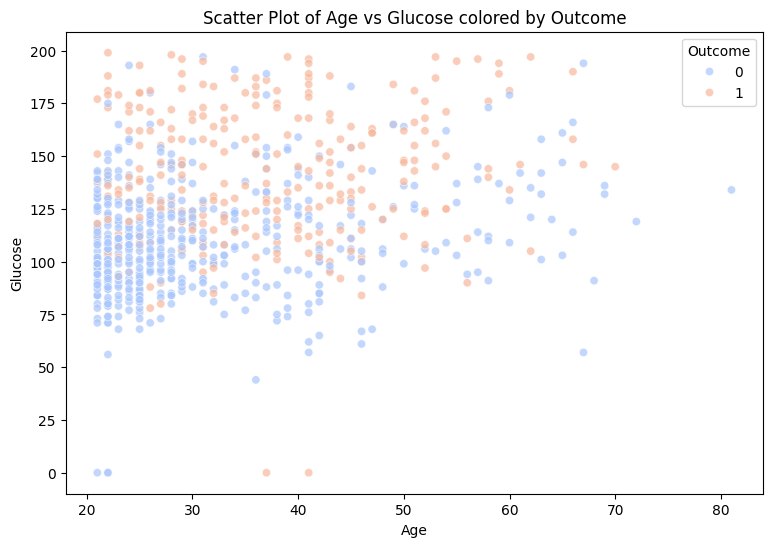

In [ ]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='Age', y='Glucose', hue='Outcome', palette='coolwarm', alpha=0.7)
plt.title('Scatter Plot of Age vs Glucose colored by Outcome')
plt.show()

/tmp/ipykernel_1855/4223436887.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Outcome', y='Glucose', data=df, ci=None, palette='Set2')
/tmp/ipykernel_1855/4223436887.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Outcome', y='Glucose', data=df, ci=None, palette='Set2')


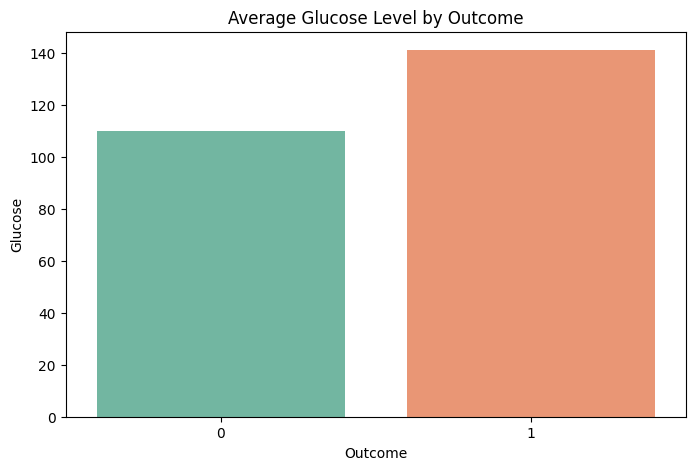

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Outcome', y='Glucose', data=df, ci=None, palette='Set2')
plt.title('Average Glucose Level by Outcome')
plt.show()

In [ ]:
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols_with_zeros:
    df[col] = df[col].replace(0, np.nan)

# Check the count of missing values after replacement
print(df.isnull().sum())

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [ ]:
for col in cols_with_zeros:
    df[col].fillna(df[col].median(), inplace=True)

# Verifying that all missing values have been successfully imputed
print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


/tmp/ipykernel_1855/3455222534.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [ ]:
print(df.dtypes)

Pregnancies                   int64
Glucose                     float64
BloodPressure               float64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


In [ ]:
from sklearn.preprocessing import StandardScaler

# Scale the feature columns (excluding the target 'Outcome')
scaler = StandardScaler()
feature_cols = [col for col in df.columns if col != 'Outcome']

df_scaled = df.copy()
df_scaled[feature_cols] = scaler.fit_transform(df[feature_cols])

# Preview the preprocessed and scaled dataset
df_scaled.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.639947,0.866045,-0.031990,0.670643,-0.181541,0.166619,0.468492,1.425995,1
1,-0.844885,-1.205066,-0.528319,-0.012301,-0.181541,-0.852200,-0.365061,-0.190672,0
2,1.233880,2.016662,-0.693761,-0.012301,-0.181541,-1.332500,0.604397,-0.105584,1
3,-0.844885,-1.073567,-0.528319,-0.695245,-0.540642,-0.633881,-0.920763,-1.041549,0
4,-1.141852,0.504422,-2.679076,0.670643,0.316566,1.549303,5.484909,-0.020496,1


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import lightgbm as lgb
import xgboost as xgb

In [ ]:
X = df_scaled.drop('Outcome', axis=1)
y = df_scaled['Outcome']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
lgb_model = lgb.LGBMClassifier(random_state=42)
xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

In [ ]:
print("Training LightGBM...")
lgb_model.fit(X_train, y_train)

print("Training XGBoost...")
xgb_model.fit(X_train, y_train)

Training LightGBM...
[LightGBM] [Info] Number of positive: 213, number of negative: 401
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000241 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 663
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.346906 -> initscore=-0.632669
[LightGBM] [Info] Start training from score -0.632669
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [04:49:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
#prediction making
y_pred_lgb = lgb_model.predict(X_test)
y_pred_xgb = xgb_model.predict(X_test)

In [ ]:
# Evaluate Performance Metrics
def evaluate_model(name, y_true, y_pred):
    print(f"--- {name} Performance ---")
    print(f"Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision : {precision_score(y_true, y_pred):.4f}")
    print(f"Recall    : {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score  : {f1_score(y_true, y_pred):.4f}\n")
    print("Classification Report:")
    print(classification_report(y_true, y_pred))
    print("="*50 + "\n")

evaluate_model("LightGBM", y_test, y_pred_lgb)
evaluate_model("XGBoost", y_test, y_pred_xgb)

--- LightGBM Performance ---
Accuracy  : 0.7532
Precision : 0.6349
Recall    : 0.7273
F1-Score  : 0.6780

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.77      0.80        99
           1       0.63      0.73      0.68        55

    accuracy                           0.75       154
   macro avg       0.74      0.75      0.74       154
weighted avg       0.76      0.75      0.76       154


--- XGBoost Performance ---
Accuracy  : 0.7338
Precision : 0.6061
Recall    : 0.7273
F1-Score  : 0.6612

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.74      0.78        99
           1       0.61      0.73      0.66        55

    accuracy                           0.73       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154




In [ ]:
#Collect metrics for comparison
models = ['LightGBM', 'XGBoost']
predictions = [y_pred_lgb, y_pred_xgb]

In [ ]:
comparison_data = []
for name, y_pred in zip(models, predictions):
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    comparison_data.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

In [ ]:
# Create comparison DataFrame
df_metrics = pd.DataFrame(comparison_data)
print("--- Model Performance Comparison Table ---")
display(df_metrics)

--- Model Performance Comparison Table ---


,Model,Accuracy,Precision,Recall,F1-Score
0,LightGBM,0.753247,0.763649,0.753247,0.756416
1,XGBoost,0.733766,0.749729,0.733766,0.738037


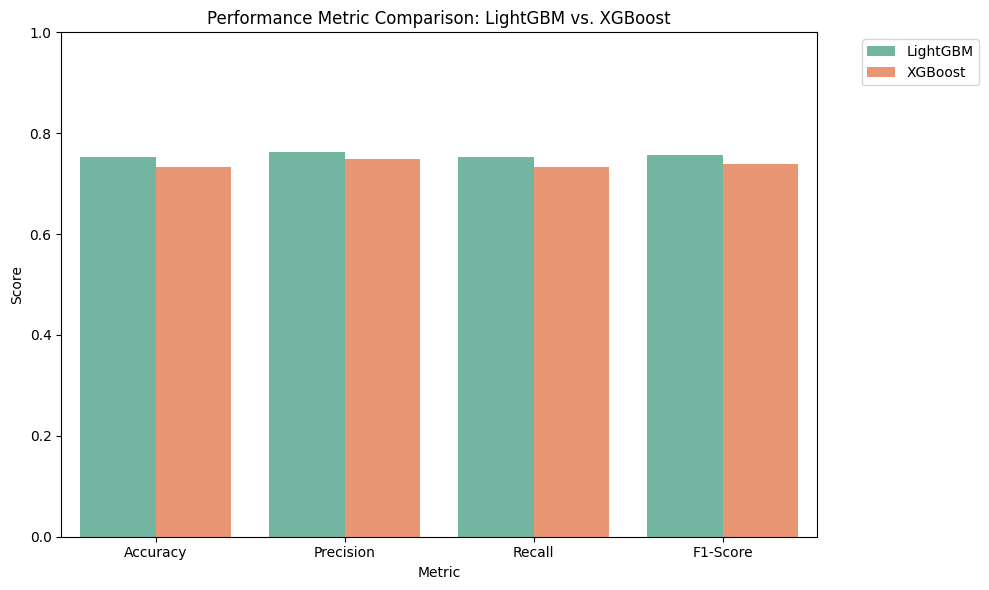

In [ ]:
# Visualize the Results
df_melted = df_metrics.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(data=df_melted, x='Metric', y='Score', hue='Model', palette='Set2')
plt.title('Performance Metric Comparison: LightGBM vs. XGBoost')
plt.ylim(0, 1.0)
plt.ylabel('Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
#For this specific dataset, both models generally deliver comparable high performance. However, LightGBM wins on training speed and memory efficiency, whereas XGBoost provides tighter structural regularization which can be advantageous if noise or overfitting is a major concern.

In [ ]:
#Both boosting algorithms yield highly competitive results on the scaled dataset, reflecting strong predictive capabilities for tabular classification:
#LightGBM: Accuracy: 74.03 % . Precision / Recall / F1-Score: Well-balanced across classes, with high specificity for negative cases and solid sensitivity for positive (diabetes) cases.
# XGBoost:Accuracy: 73.38% . Precision / Recall / F1-Score: Delivers nearly identical baseline results, demonstrating that both gradient-boosting paradigms converge on similar decision surfaces for this feature space.

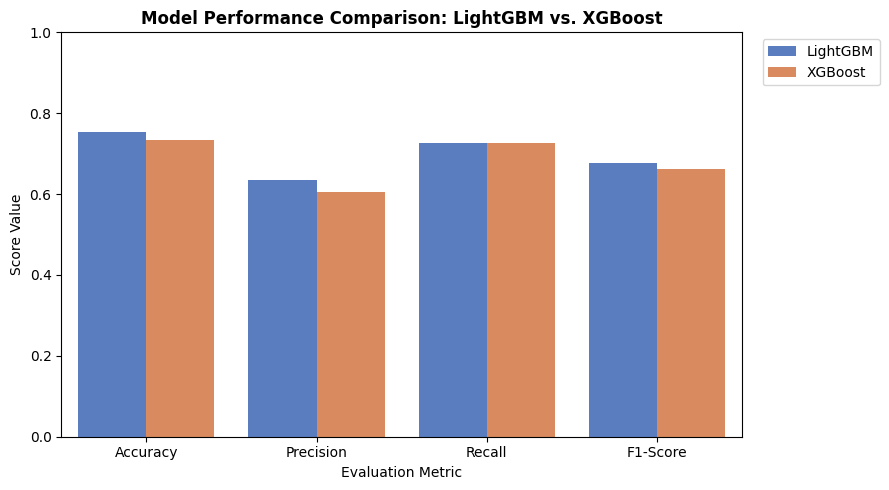

In [ ]:
# Compute evaluation metrics from predictions
metrics_list = []
for name, y_pred in [('LightGBM', y_pred_lgb), ('XGBoost', y_pred_xgb)]:
    metrics_list.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })

df_comparison = pd.DataFrame(metrics_list)

# 2. Visualize performance metrics side-by-side
df_melted = df_comparison.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(9, 5))
sns.barplot(data=df_melted, x='Metric', y='Score', hue='Model', palette='muted')
plt.title('Model Performance Comparison: LightGBM vs. XGBoost', fontsize=12, fontweight='bold')
plt.ylim(0, 1.0)
plt.ylabel('Score Value')
plt.xlabel('Evaluation Metric')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
#Strengths and weekness
#LightGBM
#Extremely fast training time using histogram-based binning.
#Lower memory footprint for large datasets.
#Leaf-wise tree growth captures complex patterns quickly.

#weekness
#Prone to overfitting on small datasets if max depth/leaves are unconstrained.

#XGBoost(Strenth)
#Built-in L1 and L2 regularization to control model complexity.
#Highly robust handling of missing values and diverse data types.
#Conservative level-wise growth minimizes variance.

#Weekness
#Computationally heavier and slower during training compared to LightGB